--- RÉSULTATS DES MODÈLES ---
--- Régression Logistique ---
Accuracy: 56.25%
Matrice de confusion :
[[18  5]
 [16  9]]


--- KNN ---
Accuracy: 64.58%
Matrice de confusion :
[[17  6]
 [11 14]]


--- Arbre de Décision ---
Accuracy: 58.33%
Matrice de confusion :
[[17  6]
 [14 11]]




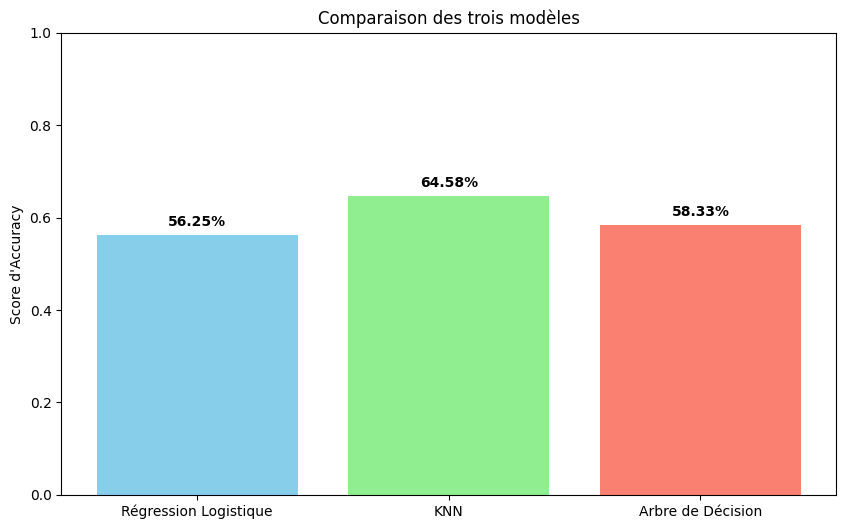

In [40]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Préparation des données
df = pd.read_csv('age_vs_poids_vs_taille_vs_sexe.csv')
df = df[df['age'] < 220].copy()

x = df[['poids', 'taille', 'age']]
y = df['sexe']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Entraînement
log_reg = LogisticRegression()
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=42)

log_reg.fit(x_train, y_train)
knn.fit(x_train, y_train)
dtree.fit(x_train, y_train)

# 3. Évaluation et stockage des scores
scores = {}
models_dict = {
    "Régression Logistique": log_reg,
    "KNN": knn,
    "Arbre de Décision": dtree
}

print("--- RÉSULTATS DES MODÈLES ---")
for name, model in models_dict.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    scores[name] = acc

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.2%}")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

# 4. Graphique de comparaison
plt.figure(figsize=(10, 6))
plt.bar(scores.keys(), scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Score d\'Accuracy')
plt.title('Comparaison des trois modèles')
plt.ylim(0, 1)

# Ajout du texte des scores sur les barres
for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.savefig('comparaison_modeles.png')
plt.show()




In [ ]:
le modele Knn est le meilleur dans la prediction car apres le test il obtient 64.58%
points d'amelioration
  avoir une dataset plus vaste sera plus mieux et plus consistant
  ajouter de nouveaux champs aiderons a mieux distinguer les filles des garcons comme activite sportive pratique
